[[-1.67799108e-16  9.91234827e-01]]
the cost : 0.008691668278240368


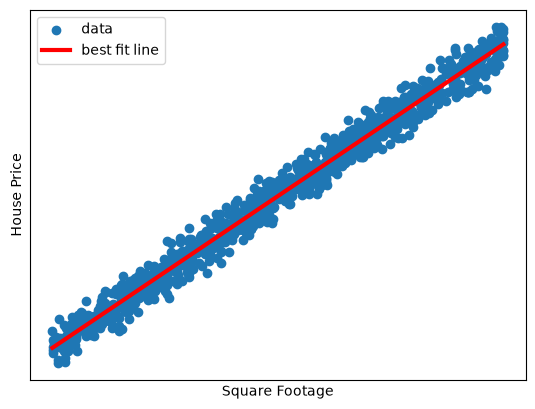

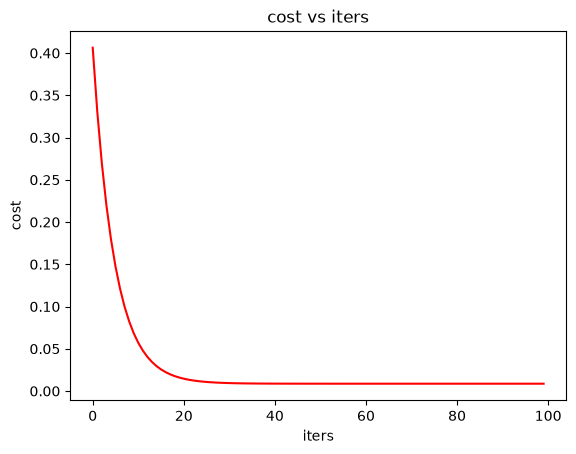

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#read data from the file.csv
data = pd.read_csv('/home/ali/python/data_csv/houses_data.csv')
data.insert(0,'X0',1)

#scaling data 
data.Square_Footage = (data.Square_Footage -data.Square_Footage.mean()) /data.Square_Footage.std()
data.House_Price = (data.House_Price -data.House_Price.mean()) /data.House_Price.std()


#data in numpy array
x_val = np.array(data.iloc[:,:2])
y_val = np.array(data.House_Price).reshape(-1,1)
theta_val = np.array([0.0 , 0.0]).reshape(1,2)


# the cost functhion
def costJ(x,y,theta):
    error = ( (x.dot(theta.T)) - y )**2
    n = np.sum(error) / ( len(x)*2 )
    return n 

#the gradian desint function 
def g_d(x,y,theta,alpha,iters):
    cost = np.zeros(iters)
    t = theta.copy()
    
    for i in range(iters):
        error = ( (x.dot(theta.T) - y) )
        for q in range(theta.shape[1]):
            t[0,q] = theta[0,q] -(alpha/len(x)) *np.sum( error *x[:,q].reshape(1000,1) )

        theta = t 
        cost[i] = costJ(x,y,theta)


    return cost ,theta


alpha = 0.1
iters = 100


cost_array , new_theta = g_d(x_val , y_val , theta_val , alpha , iters)
print(new_theta)



fig , ax = plt.subplots()
ax.scatter(x_val[:,1] , y_val,label=('data'))
x = np.linspace(data.Square_Footage.min() , data.Square_Footage.max() ,100)
f = new_theta[0,0] + new_theta[0,1]*x
ax.plot(x , f ,'r',label=('best fit line'),linewidth=3)
ax.set_xlabel('Square Footage')
ax.set_ylabel('House Price')
ax.set_xticks([])
ax.set_yticks([])
ax.legend()


fig ,ax = plt.subplots()
ax.plot(range(iters) , cost_array,'r')
ax.set_title('cost vs iters')
ax.set_xlabel('iters')
ax.set_ylabel('cost')





print('the cost :',costJ(x_val,y_val,new_theta))


